In [1]:
import yfinance as yf
data = yf.download('BTC')
data


C:\Users\A.M\AppData\Local\Temp\ipykernel_10276\1950464535.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download('BTC')
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,BTC,BTC,BTC,BTC,BTC
Date,,,,,
2025-10-15,49.270000,49.724998,48.764999,49.369999,2068700
2025-10-16,47.939999,49.369999,47.610001,49.230000,3610800
2025-10-17,47.139999,47.599998,46.279999,46.759998,3442600
2025-10-20,49.099998,49.490002,48.650002,49.029999,1739900
2025-10-21,49.500000,50.529999,47.900002,48.139999,3737600
2025-10-22,47.709999,48.320000,47.590000,47.919998,2441300
2025-10-23,48.810001,49.310001,48.150002,48.330002,1123300
2025-10-24,48.990002,49.320000,48.599998,49.250000,1291700


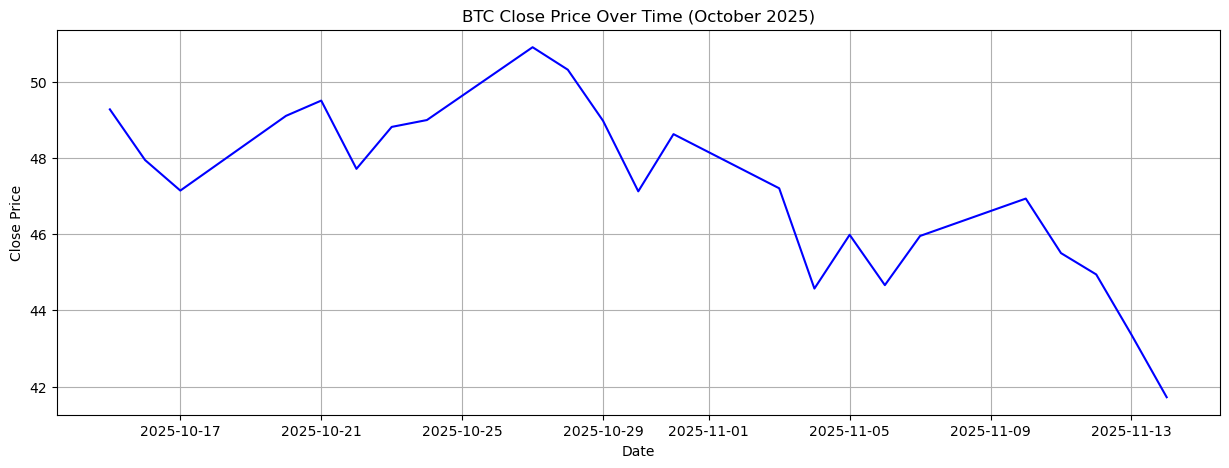

In [2]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,5))
plt.plot(data.index, data['Close'], color='blue', label='Close Price')
plt.title('BTC Close Price Over Time (October 2025)')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.grid(True)
plt.show()


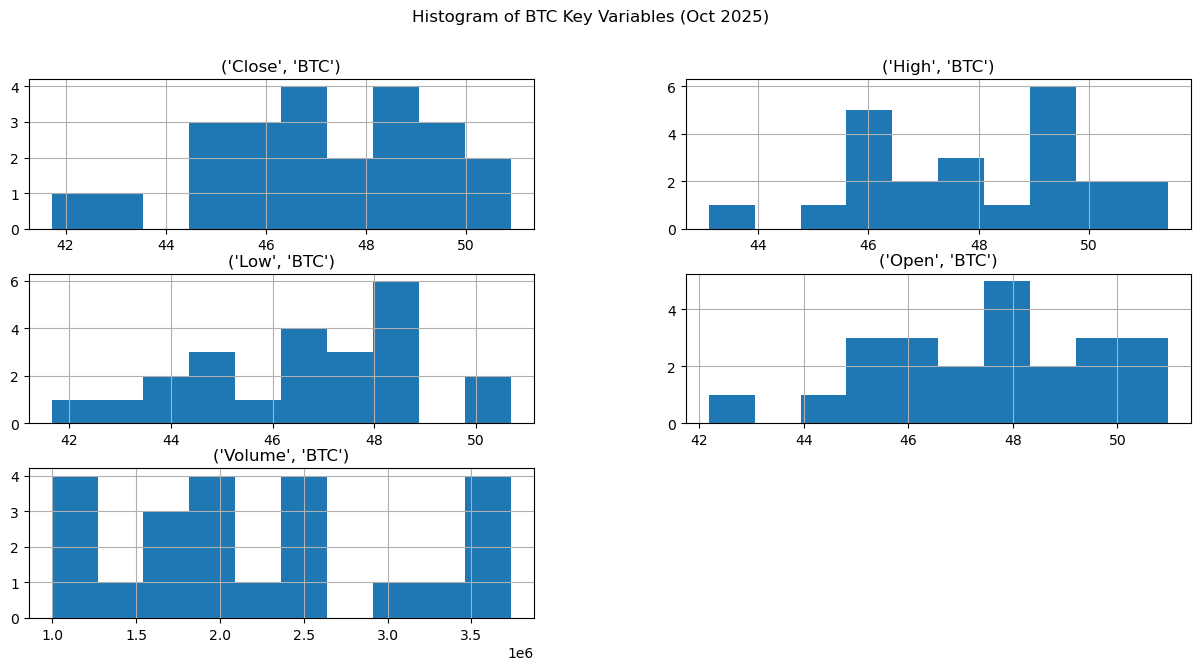

In [3]:
data.hist( figsize=(15,7))
plt.suptitle('Histogram of BTC Key Variables (Oct 2025)')
plt.show()


In [4]:
data['MA7'] = data['Close'].rolling(window=7).mean()

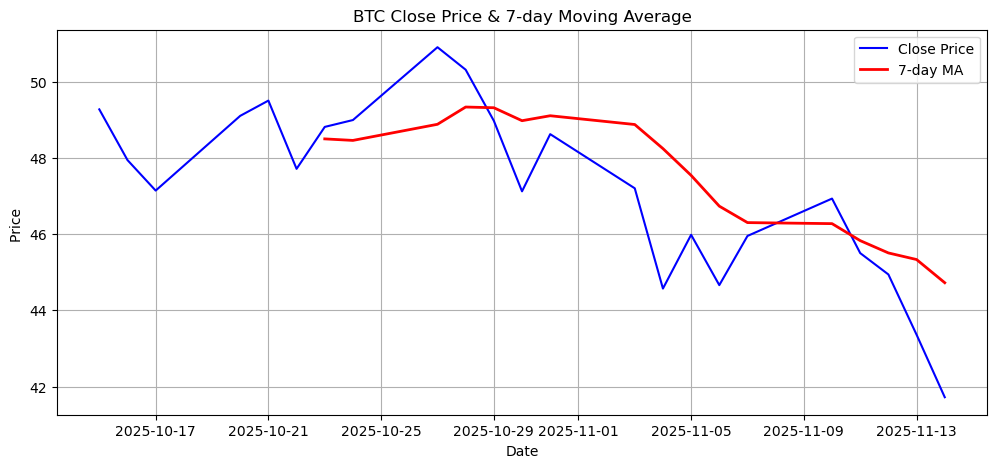

In [5]:
plt.figure(figsize=(12,5))
plt.plot(data.index, data['Close'], label='Close Price', color='blue')
plt.plot(data.index, data['MA7'], label='7-day MA', color='red', linewidth=2)
plt.title('BTC Close Price & 7-day Moving Average')
plt.xlabel('Date')
plt.ylabel('Price ')
plt.legend()
plt.grid(True)
plt.show()


In [6]:
from statsmodels.tsa.seasonal import seasonal_decompose
decomposition = seasonal_decompose(data["Close"], model='additive', period=7)
# seasonal_decompose time series ko 3 parts me TOD deta hai:
# Trend = data ka long-term direction
# Seasonality = har haftay/mahine repeat hone wala pattern
# Residual/Noise  jo bach jaye (random movement)
trend = decomposition.trend
seasonal = decomposition.seasonal
residual = decomposition.resid


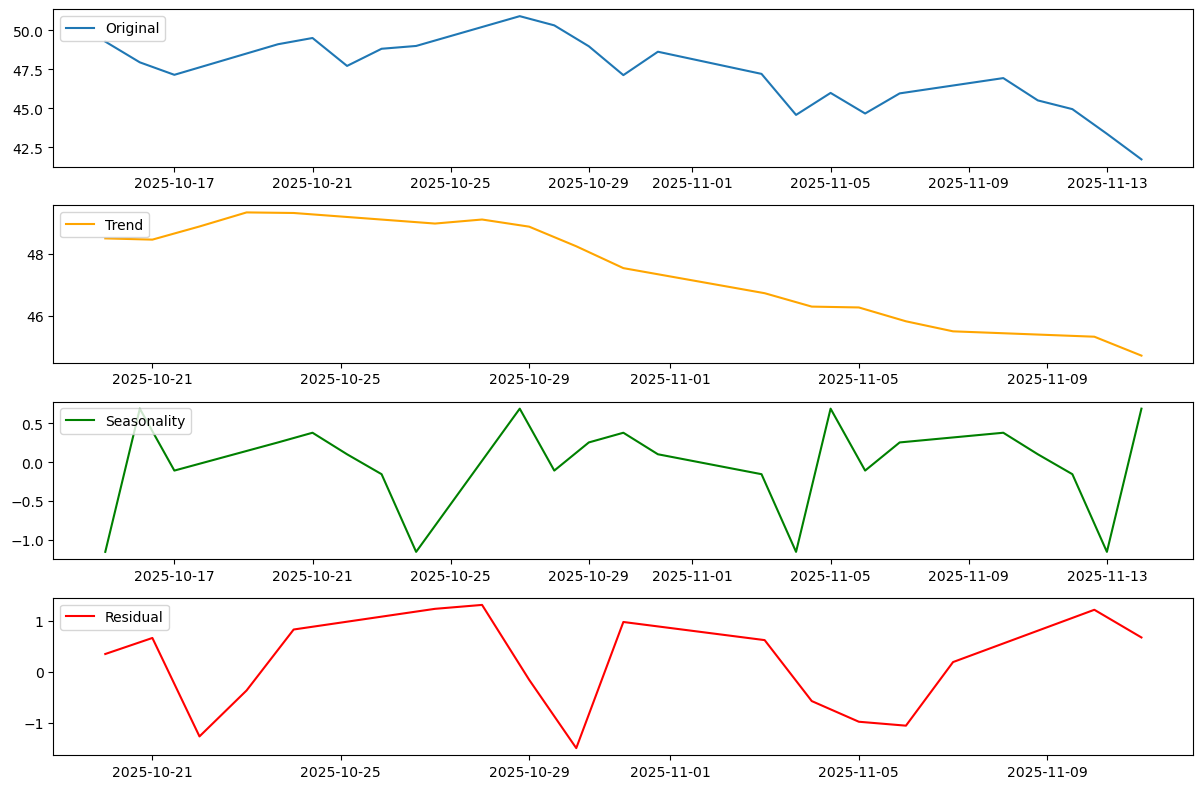

In [7]:
plt.figure(figsize=(12,8))

plt.subplot(4,1,1)
plt.plot(data["Close"], label='Original')
plt.legend(loc='upper left')

plt.subplot(4,1,2)
plt.plot(trend, label='Trend', color='orange')
plt.legend(loc='upper left')

plt.subplot(4,1,3)
plt.plot(seasonal, label='Seasonality', color='green')
plt.legend(loc='upper left')

plt.subplot(4,1,4)
plt.plot(residual, label='Residual', color='red')
plt.legend(loc='upper left')

plt.tight_layout()
plt.show()


In [8]:
from statsmodels.tsa.stattools import adfuller
volume_series = data['Volume'].dropna()

adf_result = adfuller(volume_series)

print('ADF Statistic:', adf_result[0])
print('p-value:', adf_result[1])
print('Critical Values:', adf_result[4])


ADF Statistic: -3.0918851808762757
p-value: 0.027159579059277218
Critical Values: {'1%': -3.7883858816542486, '5%': -3.013097747543462, '10%': -2.6463967573696143}


The series is Stationary

In [10]:
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error
close_series = data['Close'].dropna()


n_forecast = 5
train = close_series[:-n_forecast]
test = close_series[-n_forecast:]

model = ARIMA(close_series, order=(1,0,0))
model_fit = model.fit()
forecast = model_fit.forecast(steps=5)  
print(forecast)

forecast = model_fit.forecast(steps=n_forecast)


mae = mean_absolute_error(test, forecast)
print(f'Mean Absolute Error (MAE): {mae:.2f}')



2025-11-17    42.415804
2025-11-18    43.012451
2025-11-19    43.524073
2025-11-20    43.962785
2025-11-21    44.338977
Freq: B, Name: predicted_mean, dtype: float64
Mean Absolute Error (MAE): 2.33


C:\Users\A.M\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
C:\Users\A.M\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
C:\Users\A.M\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)


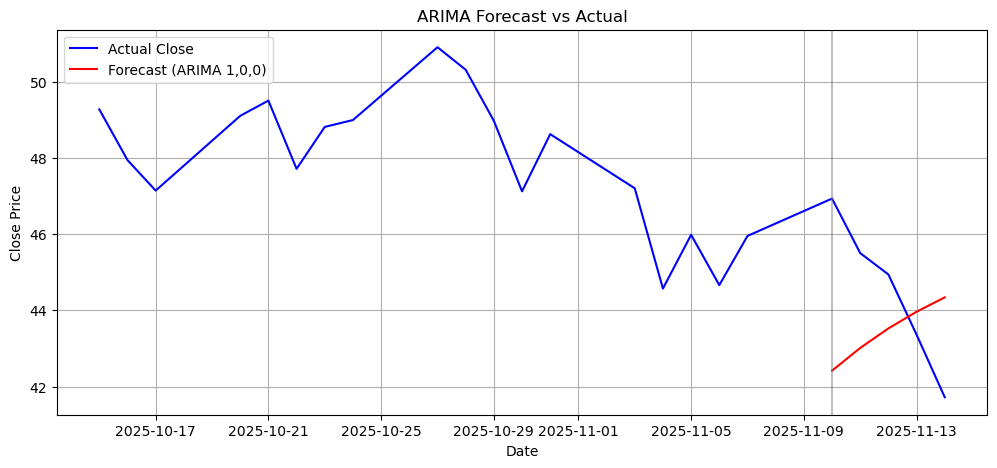

In [11]:
# Plot actual vs forecast

plt.figure(figsize=(12,5))
plt.plot(close_series.index, close_series, label='Actual Close', color='blue')
plt.plot(test.index, forecast, label='Forecast (ARIMA 1,0,0)', color='red')
plt.axvline(close_series.index[-n_forecast], color='gray', alpha=0.5)  
plt.title('ARIMA Forecast vs Actual')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.legend()
plt.grid(True)
plt.show()
